<a href="https://colab.research.google.com/github/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/blob/main/S%C3%A9ries_temporais_Autocorrela%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-905765935.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time = pd.date_range(start='2025-01-01', periods=n, freq='T')  # 1 minuto de intervalo


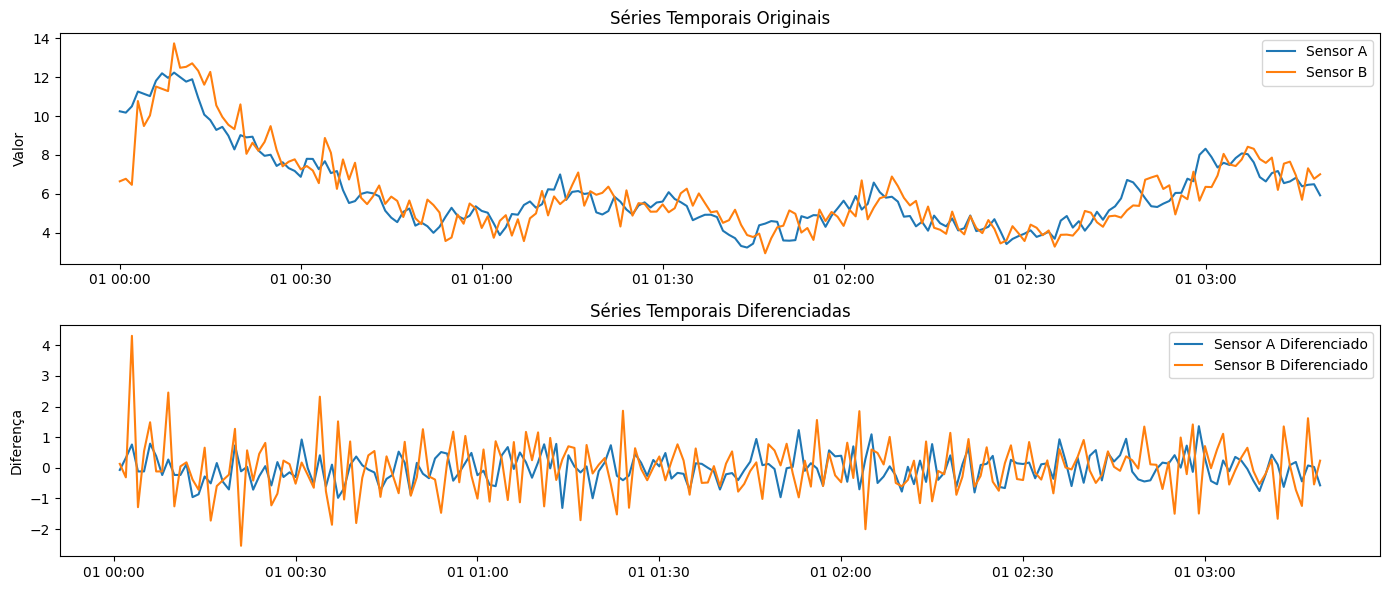

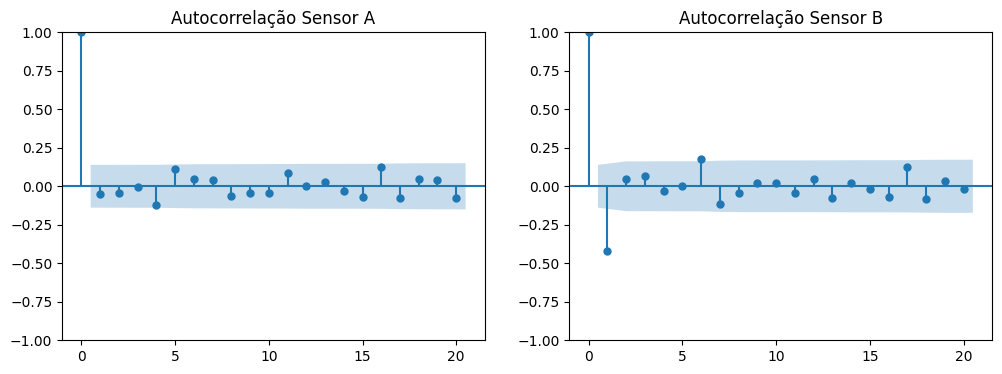

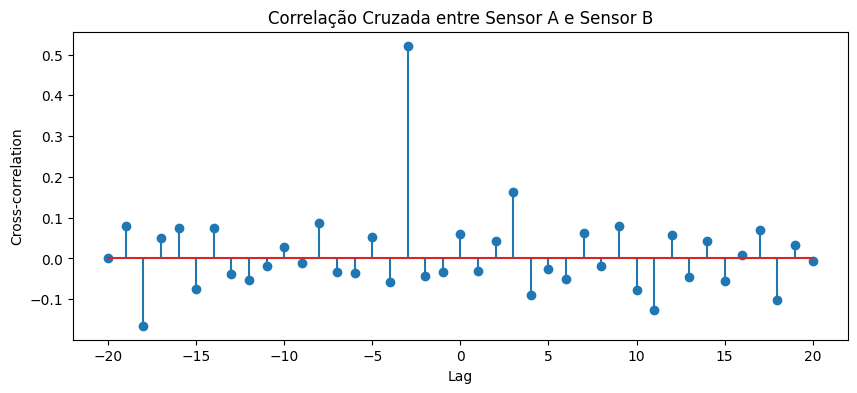

Lag de maior correlação: -3 minutos
Valor da correlação: 0.522


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
from statsmodels.graphics.tsaplots import plot_acf

# -------------------------------
# 1️⃣ Criando séries de exemplo
# -------------------------------
np.random.seed(42)
n = 200
time = pd.date_range(start='2025-01-01', periods=n, freq='T')  # 1 minuto de intervalo

# Sensor A: tendência + ruído
A = pd.Series(np.cumsum(np.random.normal(0, 0.5, n)) + 10, index=time)

# Sensor B: influência de A com lag + ruído
B = pd.Series(np.roll(A, 3) + np.random.normal(0, 0.5, n), index=time)

# -------------------------------
# 2️⃣ Diferenciação (removendo tendência)
# -------------------------------
A_diff = A.diff().dropna()
B_diff = B.diff().dropna()

# -------------------------------
# 3️⃣ Plotando séries originais e diferenciadas
# -------------------------------
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(A, label='Sensor A')
plt.plot(B, label='Sensor B')
plt.title("Séries Temporais Originais")
plt.ylabel("Valor")
plt.legend()

plt.subplot(2,1,2)
plt.plot(A_diff, label='Sensor A Diferenciado')
plt.plot(B_diff, label='Sensor B Diferenciado')
plt.title("Séries Temporais Diferenciadas")
plt.ylabel("Diferença")
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# 4️⃣ Autocorrelação de cada série diferenciada
# -------------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_acf(A_diff, ax=plt.gca(), lags=20)
plt.title("Autocorrelação Sensor A")

plt.subplot(1,2,2)
plot_acf(B_diff, ax=plt.gca(), lags=20)
plt.title("Autocorrelação Sensor B")
plt.show()

# -------------------------------
# 5️⃣ Correlação cruzada
# -------------------------------
def cross_correlation(x, y, max_lag):
    lags = np.arange(-max_lag, max_lag+1)
    corr = [x.corr(y.shift(lag)) for lag in lags]
    return lags, corr

max_lag = 20
lags, corr_values = cross_correlation(A_diff, B_diff, max_lag)

plt.figure(figsize=(10,4))
plt.stem(lags, corr_values)
plt.xlabel("Lag")
plt.ylabel("Cross-correlation")
plt.title("Correlação Cruzada entre Sensor A e Sensor B")
plt.show()

# -------------------------------
# 6️⃣ Lag de maior correlação
# -------------------------------
best_lag = lags[np.argmax(np.abs(corr_values))]
print(f"Lag de maior correlação: {best_lag} minutos")
print(f"Valor da correlação: {corr_values[np.argmax(np.abs(corr_values))]:.3f}")


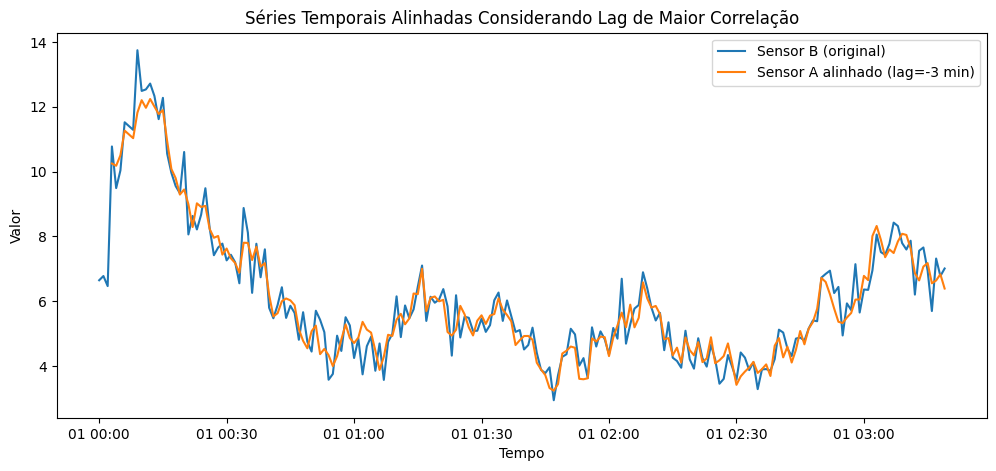

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Ajustando A pelo lag
# -------------------------------
lag = -3  # minutos, conforme cross-correlation
A_aligned = A.shift(-lag)  # desloca A para frente, pois lag negativo

# Truncar séries para o mesmo tamanho após shift
min_len = min(len(A_aligned), len(B))
A_aligned = A_aligned.iloc[:min_len]
B_trunc = B.iloc[:min_len]

# -------------------------------
# 2️⃣ Plotando séries alinhadas
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(B_trunc, label='Sensor B (original)')
plt.plot(A_aligned, label=f'Sensor A alinhado (lag={lag} min)')
plt.title("Séries Temporais Alinhadas Considerando Lag de Maior Correlação")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.legend()
plt.show()
